In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [349]:
df = pd.read_csv('data/course_lead_scoring.csv')

In [350]:
df.isna().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [351]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [352]:
categorical_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['number']).columns

df[categorical_cols] = df[categorical_cols].fillna('NA')
df[num_cols] = df[num_cols].fillna(0.0)

In [353]:
df.isna().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [354]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [355]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [356]:
df_train.nunique()

lead_source                   6
industry                      8
number_of_courses_viewed     10
annual_income               765
employment_status             5
location                      8
interaction_count             9
lead_score                  101
dtype: int64

# ROC AUC feature importance

In [357]:
num_feats = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']

results = []

for col in num_feats:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        # print(y_train)
        df_train[col] =  -df_train[col]
        auc = roc_auc_score(y_train, df_train)
    results.append((col, auc))

# Show sorted, best on top
results = sorted(results, key=lambda t: t[1], reverse=True)
results

[('number_of_courses_viewed', 0.7635680590007088),
 ('interaction_count', 0.738270176293409),
 ('lead_score', 0.6144993577250176),
 ('annual_income', 0.5519578313253012)]

### Question 1: Which numerical variable (among the following 4) has the highest AUC?
#### Answer is number_of_courses_viewed

# Training the model

In [358]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[list(categorical_cols) + num_feats].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[list(categorical_cols) + num_feats].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [359]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

In [360]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [361]:
y_pred = model.predict_proba(X_val)[:, 1]

In [362]:
auc = roc_auc_score(y_val, y_pred)   # y_pred are your probabilities for class 1
print("AUC:", round(auc, 3))

AUC: 0.817


### Question 2: What's the AUC of this model on the validation dataset? (round to 3 digits)
#### Answer is 0.72

# Precision and Recall

In [363]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [364]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    # Precision
    p = tp / (tp + fp)

    # Recall
    r = tp / (tp + fn)

    # F1 score (avoid divide by zero)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

    scores.append((t, p, r, f1))

pr_table = pd.DataFrame(scores, columns=['threshold', 'precision', 'recall', 'f1'])
# Find threshold with max F1
best = pr_table.loc[pr_table['f1'].idxmax()]
print(best)
    

threshold    0.570000
precision    0.732394
recall       0.912281
f1           0.812500
Name: 57, dtype: float64


/tmp/ipykernel_6503/3131774094.py:15: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


In [365]:
columns = ['threshold', 'precision', 'recall', 'f1']
df_scores = pd.DataFrame(scores, columns=columns)

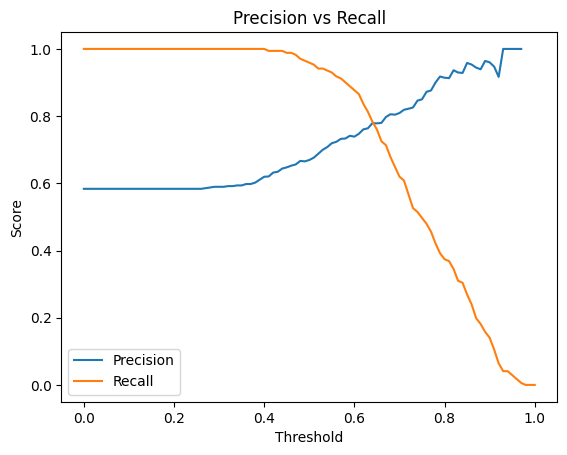

In [366]:
plt.plot(df_scores.threshold, df_scores['precision'], label='Precision')
plt.plot(df_scores.threshold, df_scores['recall'], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall')
plt.legend()

### At which threshold precision and recall curves intersect?
#### Answer: 0.745

#  F1 score

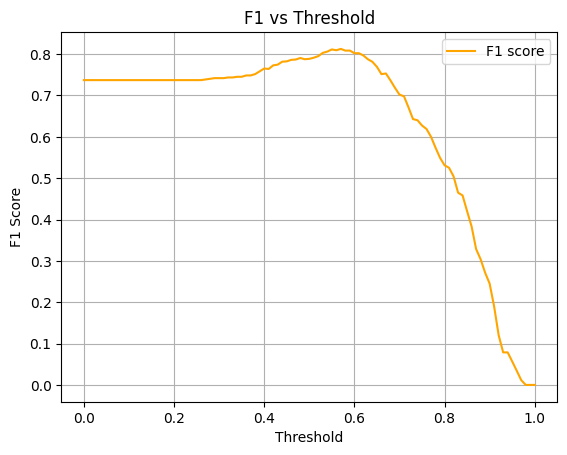

In [367]:
plt.plot(df_scores.threshold, df_scores['f1'], label='F1 score', color='orange')

plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

### Question: At which threshold F1 is maximal?
#### Answer is 0.54

# 5-Fold CV

In [368]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical_cols + num_feats].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [369]:
dv, model = train(df_train, y_train, C=0.001)


KeyError: "None of [Index(['lead_sourcelead_score', 'industrynumber_of_courses_viewed',\n       'employment_statusinteraction_count', 'locationannual_income'],\n      dtype='object')] are in the [columns]"

In [ ]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [ ]:
y_pred = predict(df_val, dv, model)

In [ ]:
!pip install tqdm

In [ ]:
from tqdm.auto import tqdm

In [ ]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))